Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Reloading Tuner from kt_tuning_dir\water_demand_lstm\tuner0.json
--- Commencing Hyperparameter Search ---

--- Tuning Complete! Optimal Architecture Parameters: ---
-> LSTM Layer 1 Units: 64
-> Dropout 1: 0.2
-> LSTM Layer 2 Units: 128
-> LSTM Layer 3 Units: 48
-> Dense Layer 1 Units: 96
-> Learning Rate: 0.001

--- Training Best Model on Full Epochs ---


d:\New folder\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 100ms/step - loss: 0.0551 - mae: 0.1777 - val_loss: 0.0180 - val_mae: 0.1143 - learning_rate: 0.0010
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.0290 - mae: 0.1282 - val_loss: 0.0435 - val_mae: 0.1865 - learning_rate: 0.0010
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0208 - mae: 0.1145 - val_loss: 0.0090 - val_mae: 0.0761 - learning_rate: 0.0010
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - loss: 0.0153 - mae: 0.0856 - val_loss: 0.0132 - val_mae: 0.0936 - learning_rate: 0.0010
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0203 - mae: 0.1051 - val_loss: 0.0127 - val_mae: 0.0922 - learning_rate: 0.0010
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0147 - mae: 0.0870 - val_loss: 0.0144 - val_mae: 0.1016 - learning_rate: 0.0010
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0263 - mae: 0.1099 - val_loss: 0.0155 - val_mae: 0.1055 - learning_rate: 0.0010
Epoc

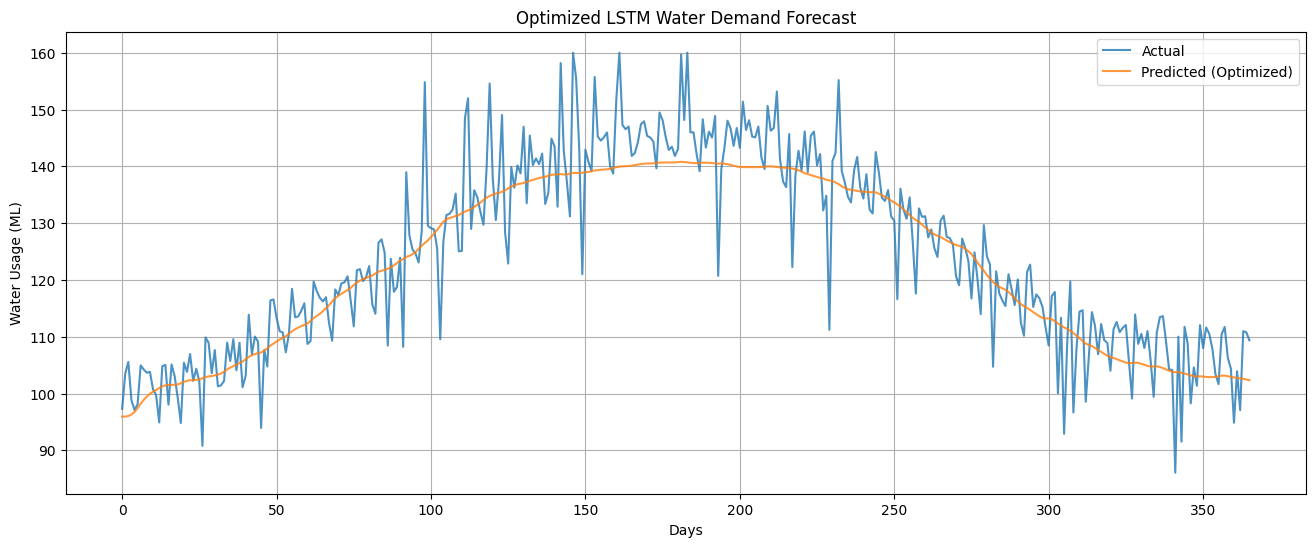

In [ ]:
%pip install numpy pandas matplotlib scikit-learn tensorflow joblib keras-tuner
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import keras_tuner as kt

df = pd.read_csv("water_consumption_dataset.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

target = "Total_Daily_Usage_ML"


df['month_sin'] = np.sin(2*np.pi*df['Month']/12)
df['month_cos'] = np.cos(2*np.pi*df['Month']/12)
df['day_sin'] = np.sin(2*np.pi*df['Day_of_Year']/365)
df['day_cos'] = np.cos(2*np.pi*df['Day_of_Year']/365)

for lag in [1,2,3,5,7,14,21,30,60,90,365]:
    df[f'lag_{lag}'] = df[target].shift(lag)


df['ma_7'] = df[target].rolling(7).mean()
df['ma_30'] = df[target].rolling(30).mean()
df['std_7'] = df[target].rolling(7).std()
df['std_30'] = df[target].rolling(30).std()
df['rolling_max_7'] = df[target].rolling(7).max()
df['rolling_min_7'] = df[target].rolling(7).min()


df['diff_1'] = df[target].diff(1)
df['diff_3'] = df[target].diff(3)
df['diff_7'] = df[target].diff(7)

df.dropna(inplace=True)

features = [
    'Day_of_Week', 'Month', 'Year', 'Day_of_Year', 'Is_Weekend', 'Holiday_Flag',
    'Temperature_C', 'Rainfall_mm', 'Humidity_pct', 'Evaporation_Rate_mm',
    'Population', 'Household_Count', 'Urbanization_Index', 'Pump_Status', 'Reservoir_Level_pct',
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30', 'lag_60', 'lag_90', 'lag_365',
    'ma_7', 'ma_30', 'std_7', 'std_30', 'rolling_max_7', 'rolling_min_7', 'diff_1', 'diff_3', 'diff_7'
]


split_row = int(len(df) * 0.8)
train_df = df.iloc[:split_row]
test_df = df.iloc[split_row:]

feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

feature_scaler.fit(train_df[features])
target_scaler.fit(train_df[[target]])

scaled_features = feature_scaler.transform(df[features])
scaled_target = target_scaler.transform(df[[target]])


window_size = 60

def create_sequences(features, target, window):
    X, y = [], []
    for i in range(window, len(features)):
        X.append(features[i-window:i])
        y.append(target[i])
    return np.array(X), np.array(y)

X_all, y_all = create_sequences(scaled_features, scaled_target, window_size)

sequence_split = split_row - window_size
X_train = X_all[:sequence_split]
y_train = y_all[:sequence_split]
X_test = X_all[sequence_split:]
y_test = y_all[sequence_split:]

validation_size = int(len(X_train) * 0.1)

X_fit = X_train[:-validation_size]
y_fit = y_train[:-validation_size]
X_val = X_train[-validation_size:]
y_val = y_train[-validation_size:]

y_original = target_scaler.inverse_transform(y_train)
peak_threshold = np.percentile(y_original, 90)
sample_weights = np.where(y_original.flatten() > peak_threshold, 3.0, 1.0)


def build_model(hp):
    model = Sequential()
    
    model.add(LSTM(
        units=hp.Int('lstm_1_units', min_value=64, max_value=256, step=64),
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ))
    model.add(Dropout(hp.Float('dropout_1', min_value=0.1, max_value=0.3, step=0.1)))
    
    model.add(LSTM(
        units=hp.Int('lstm_2_units', min_value=32, max_value=128, step=32),
        return_sequences=True
    ))
    model.add(Dropout(hp.Float('dropout_2', min_value=0.1, max_value=0.3, step=0.1)))
    
    model.add(LSTM(
        units=hp.Int('lstm_3_units', min_value=16, max_value=64, step=16)
    ))
    model.add(Dropout(hp.Float('dropout_3', min_value=0.0, max_value=0.2, step=0.1)))
    
    model.add(Dense(units=hp.Int('dense_1_units', min_value=32, max_value=128, step=32), activation='relu'))
    model.add(Dense(units=hp.Int('dense_2_units', min_value=16, max_value=64, step=16), activation='relu'))
    model.add(Dense(1))
    

    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 5e-4])
    
    model.compile(
        optimizer=Adam(learning_rate=lr, clipnorm=1.0),
        loss='mse',
        metrics=['mae']
    )
    return model


tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,         
    executions_per_trial=1,  
    directory='kt_tuning_dir',
    project_name='water_demand_lstm'
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6)

print("--- Commencing Hyperparameter Search ---")
tuner.search(
    X_fit, y_fit,
    sample_weight=sample_weights[:len(X_fit)],
    validation_data=(X_val, y_val),
    epochs=50,                
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n--- Tuning Complete! Optimal Architecture Parameters: ---")
print(f"-> LSTM Layer 1 Units: {best_hps.get('lstm_1_units')}")
print(f"-> Dropout 1: {best_hps.get('dropout_1')}")
print(f"-> LSTM Layer 2 Units: {best_hps.get('lstm_2_units')}")
print(f"-> LSTM Layer 3 Units: {best_hps.get('lstm_3_units')}")
print(f"-> Dense Layer 1 Units: {best_hps.get('dense_1_units')}")
print(f"-> Learning Rate: {best_hps.get('learning_rate')}")


print("\n--- Training Best Model on Full Epochs ---")
model = tuner.hypermodel.build(best_hps)

full_early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
full_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

history = model.fit(
    X_fit, y_fit,
    sample_weight=sample_weights[:len(X_fit)],
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    shuffle=False,
    callbacks=[full_early_stop, full_reduce_lr],
    verbose=1
)

predictions = model.predict(X_test)
predictions_actual = target_scaler.inverse_transform(predictions)
y_test_actual = target_scaler.inverse_transform(y_test)

mae = mean_absolute_error(y_test_actual, predictions_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions_actual))
r2 = r2_score(y_test_actual, predictions_actual)

print("\n====================")
print("Optimized Model Performance:")
print("MAE :", round(mae, 4))
print("RMSE:", round(rmse, 4))
print("R²  :", round(r2, 4))
print("Accuracy:", round(r2*100, 2), "%")
print("====================")


